In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r'C:\Users\User\Downloads\Data Analyst Project\Upi_Fraud_Analysis\Data\upi_fraud_cleaned.csv')

In [8]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

total_transactions = len(df)

total_amount = df["Amount"].sum()

average_amount = df["Amount"].mean()

fraud_transactions = df["FraudFlag"].sum()

fraud_rate = (fraud_transactions / total_transactions) * 100

fraud_amount = df.loc[df["FraudFlag"] == True, "Amount"].sum()

non_fraud_amount = df.loc[df["FraudFlag"] == False, "Amount"].sum()

print("=" * 70)
print("UPI FRAUD ANALYTICS — KEY METRICS")
print("=" * 70)

print(f"Total Transactions       : {total_transactions:,}")
print(f"Total Transaction Value  : ₹{total_amount:,.2f}")
print(f"Average Transaction      : ₹{average_amount:,.2f}")
print(f"Fraud Transactions       : {fraud_transactions:,}")
print(f"Fraud Rate               : {fraud_rate:.2f}%")
print(f"Fraud Transaction Value  : ₹{fraud_amount:,.2f}")
print(f"Non-Fraud Transaction Value: ₹{non_fraud_amount:,.2f}")

UPI FRAUD ANALYTICS — KEY METRICS
Total Transactions       : 10,000
Total Transaction Value  : ₹50,044,606.29
Average Transaction      : ₹5,004.46
Fraud Transactions       : 965
Fraud Rate               : 9.65%
Fraud Transaction Value  : ₹4,804,244.04
Non-Fraud Transaction Value: ₹45,240,362.25


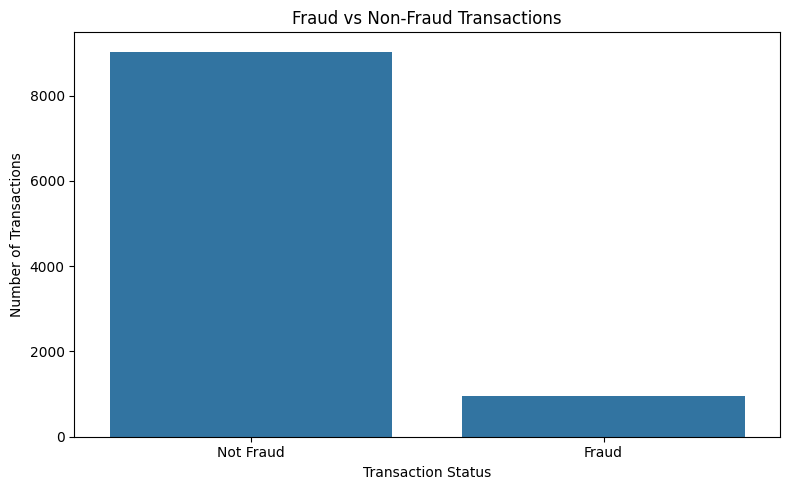

In [ ]:
fraud_counts = df["FraudStatus"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=fraud_counts.index,
    y=fraud_counts.values
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

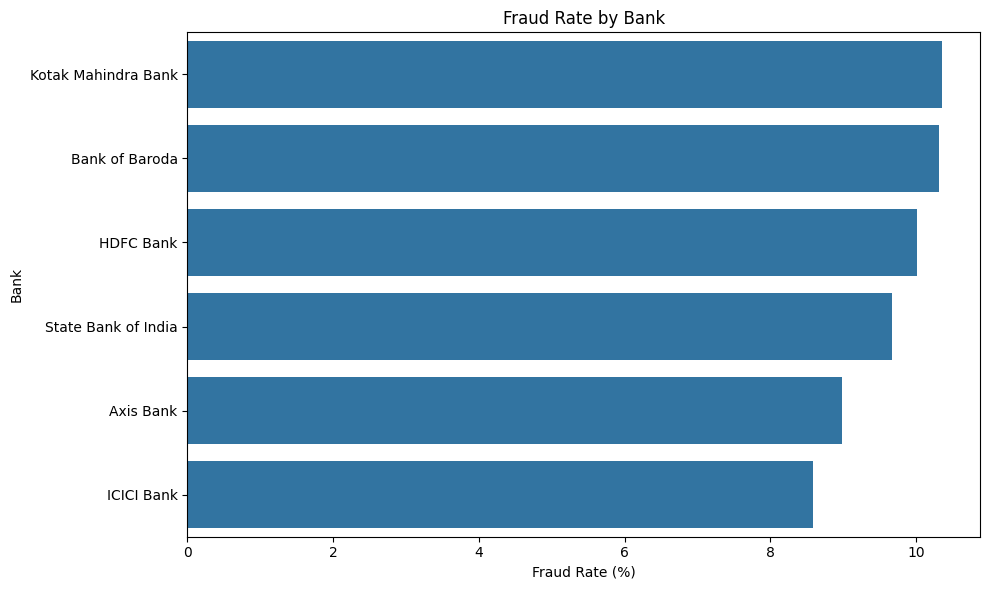

In [ ]:
bank_fraud = (
    df.groupby("BankName")["FraudFlag"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=bank_fraud.values,
    y=bank_fraud.index
)

plt.title("Fraud Rate by Bank")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()

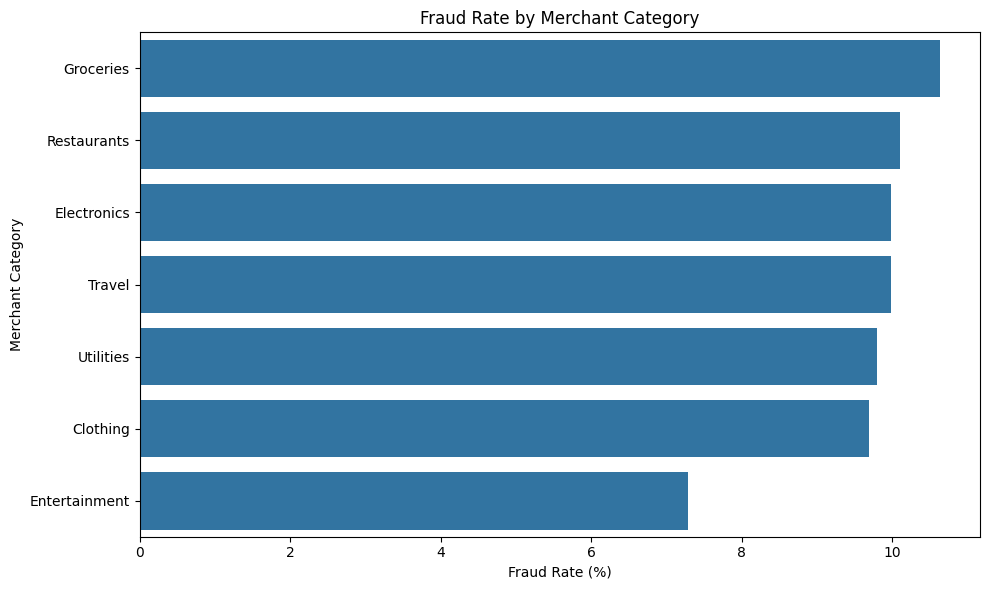

In [ ]:
merchant_fraud = (
    df.groupby("MerchantCategory")["FraudFlag"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=merchant_fraud.values,
    y=merchant_fraud.index
)

plt.title("Fraud Rate by Merchant Category")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Merchant Category")
plt.tight_layout()
plt.show()

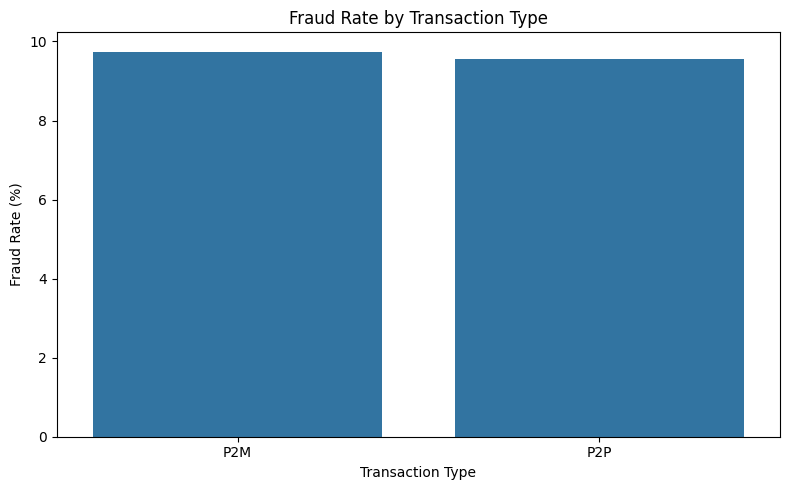

In [12]:
transaction_fraud = (
    df.groupby("TransactionType")["FraudFlag"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=transaction_fraud.index,
    y=transaction_fraud.values
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

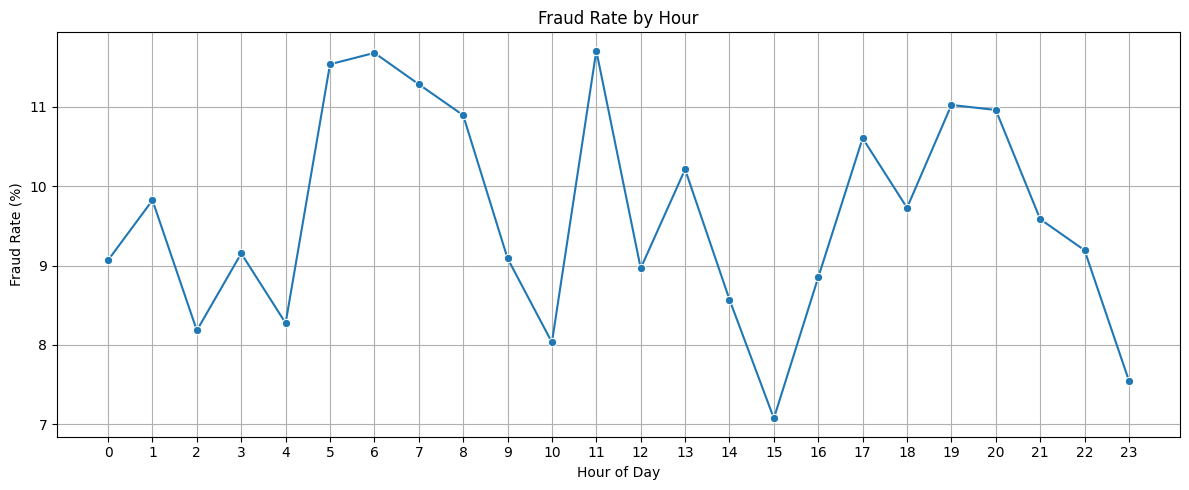

In [13]:
hourly_fraud = (
    df.groupby("Hour")["FraudFlag"]
    .mean() * 100
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_fraud.index,
    y=hourly_fraud.values,
    marker="o"
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

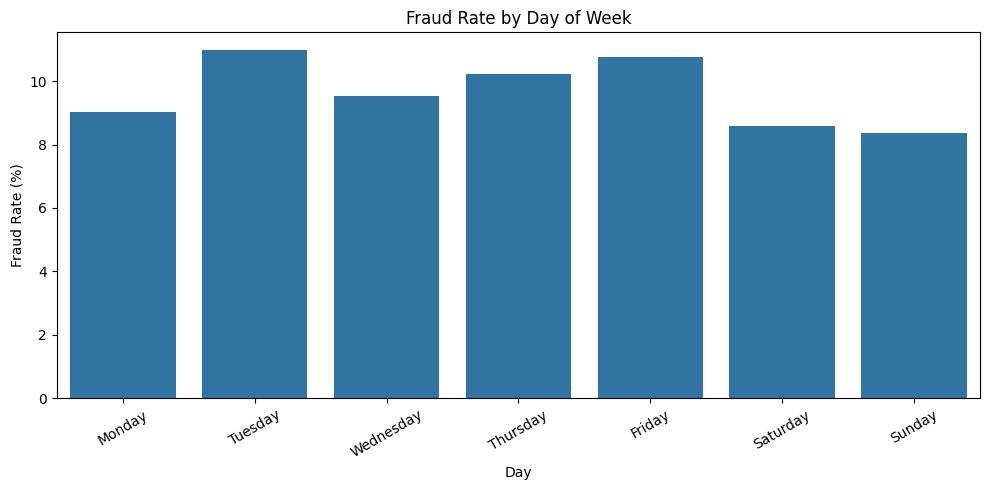

In [14]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_fraud = (
    df.groupby("DayOfWeek")["FraudFlag"]
    .mean()
    .reindex(day_order) * 100
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=daily_fraud.index,
    y=daily_fraud.values
)

plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


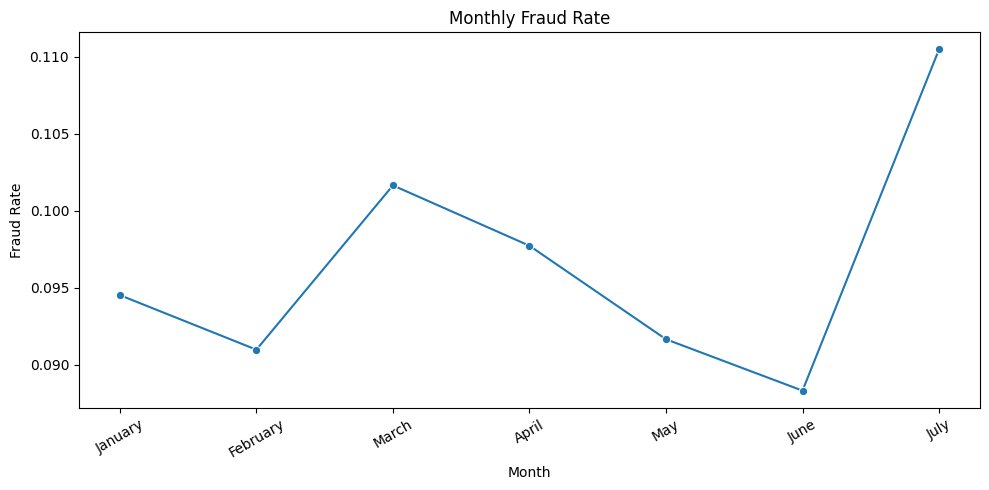

In [15]:
monthly_fraud = (
    df.groupby(["Month", "MonthName"])["FraudFlag"]
    .mean()
    .reset_index()
    .sort_values("Month")
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_fraud,
    x="MonthName",
    y="FraudFlag",
    marker="o"
)

plt.title("Monthly Fraud Rate")
plt.xlabel("Month")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



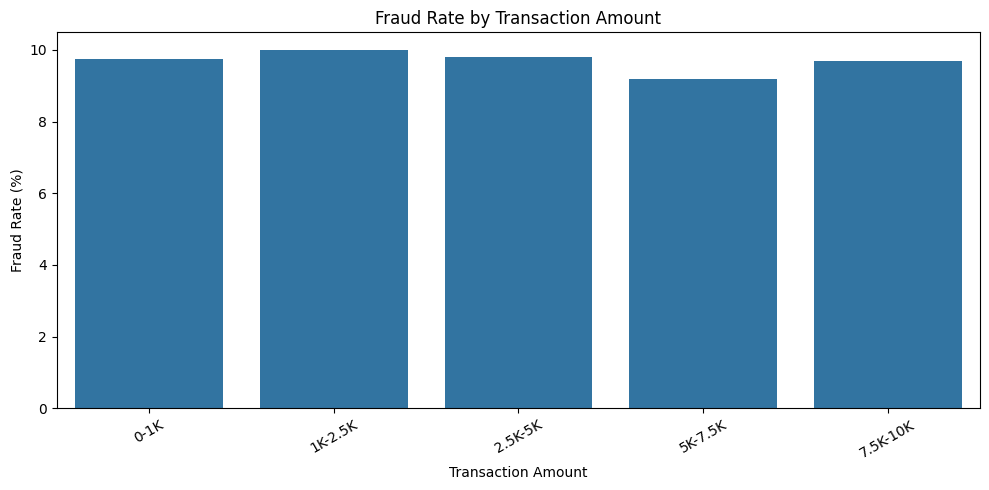

In [16]:
amount_fraud = (
    df.groupby("AmountBand", observed=True)["FraudFlag"]
    .mean() * 100
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=amount_fraud.index,
    y=amount_fraud.values
)

plt.title("Fraud Rate by Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



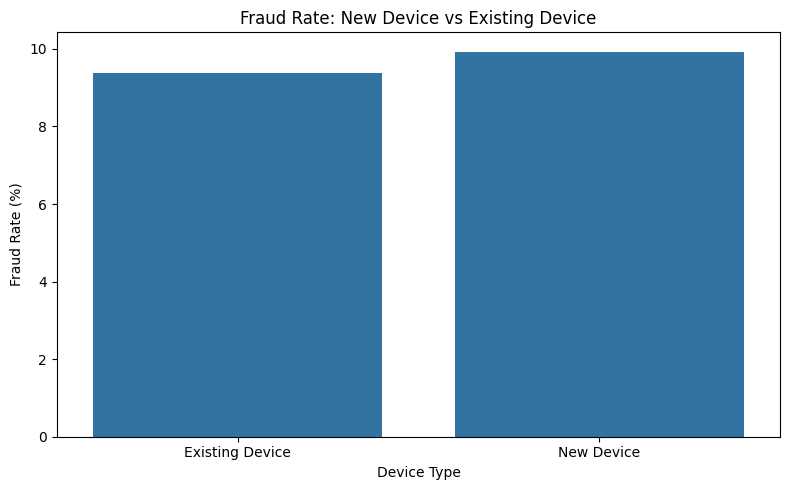

In [17]:
device_fraud = (
    df.groupby("NewDevice")["FraudFlag"]
    .mean() * 100
)

device_fraud.index = [
    "Existing Device" if x == False else "New Device"
    for x in device_fraud.index
]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=device_fraud.index,
    y=device_fraud.values
)

plt.title("Fraud Rate: New Device vs Existing Device")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()


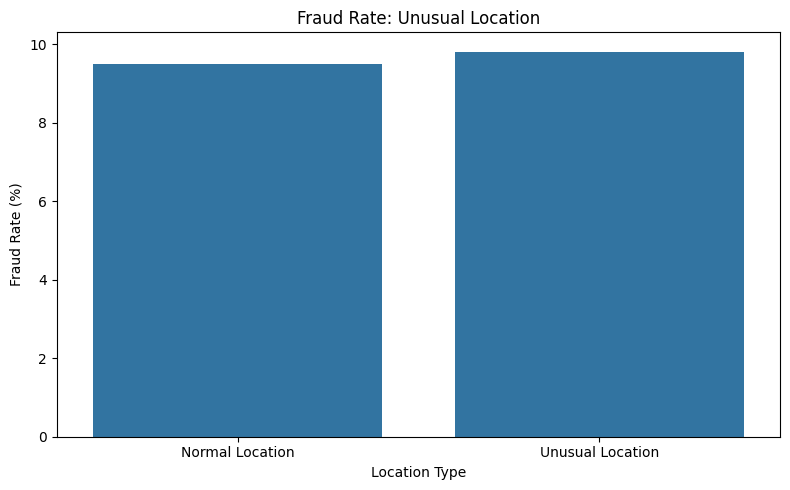

In [18]:
location_fraud = (
    df.groupby("UnusualLocation")["FraudFlag"]
    .mean() * 100
)

location_fraud.index = [
    "Normal Location" if x == False else "Unusual Location"
    for x in location_fraud.index
]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=location_fraud.index,
    y=location_fraud.values
)

plt.title("Fraud Rate: Unusual Location")
plt.xlabel("Location Type")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()



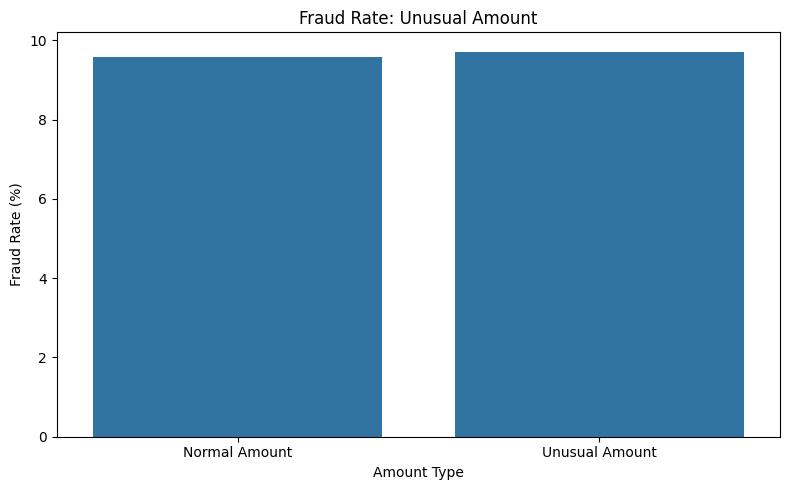

In [19]:
amount_flag_fraud = (
    df.groupby("UnusualAmount")["FraudFlag"]
    .mean() * 100
)

amount_flag_fraud.index = [
    "Normal Amount" if x == False else "Unusual Amount"
    for x in amount_flag_fraud.index
]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=amount_flag_fraud.index,
    y=amount_flag_fraud.values
)

plt.title("Fraud Rate: Unusual Amount")
plt.xlabel("Amount Type")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()



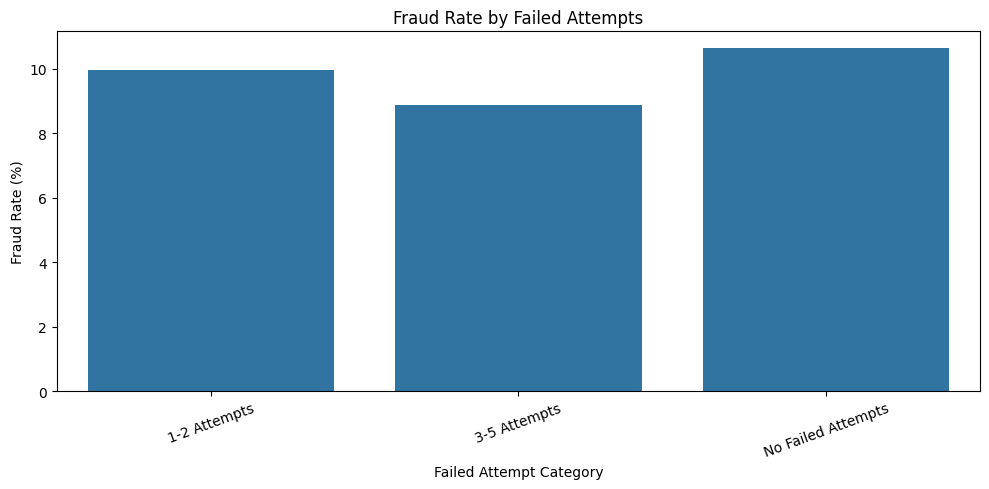

In [20]:
failed_fraud = (
    df.groupby("FailedAttemptCategory", observed=True)["FraudFlag"]
    .mean() * 100
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=failed_fraud.index,
    y=failed_fraud.values
)

plt.title("Fraud Rate by Failed Attempts")
plt.xlabel("Failed Attempt Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



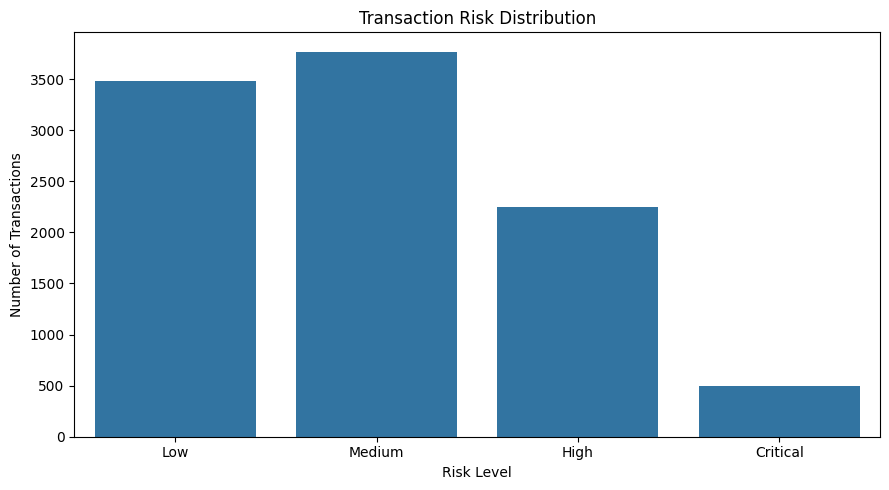

In [21]:
risk_counts = (
    df["RiskLevel"]
    .value_counts()
    .reindex(["Low", "Medium", "High", "Critical"])
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Transaction Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


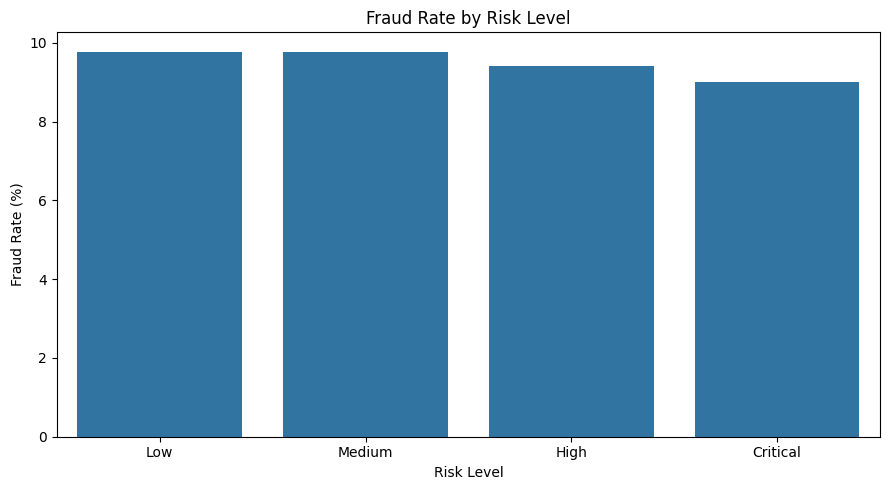

In [22]:
risk_fraud = (
    df.groupby("RiskLevel", observed=True)["FraudFlag"]
    .mean()
    .reindex(["Low", "Medium", "High", "Critical"])
    * 100
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=risk_fraud.index,
    y=risk_fraud.values
)

plt.title("Fraud Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()


In [23]:
top_fraud = (
    df[df["FraudFlag"] == True]
    .sort_values("Amount", ascending=False)
    .head(10)
)

print("\n" + "=" * 70)
print("TOP 10 HIGHEST VALUE FRAUD TRANSACTIONS")
print("=" * 70)

print(
    top_fraud[
        [
            "TransactionID",
            "Amount",
            "BankName",
            "MerchantCategory",
            "TransactionType",
            "RiskScore",
            "RiskLevel"
        ]
    ].to_string(index=False)
)



TOP 10 HIGHEST VALUE FRAUD TRANSACTIONS
 TransactionID  Amount            BankName MerchantCategory TransactionType  RiskScore RiskLevel
  967555682331 9995.33      Bank of Baroda      Electronics             P2P         25       Low
  430113440245 9974.75 State Bank of India      Electronics             P2P         50    Medium
  451468806818 9973.66      Bank of Baroda        Utilities             P2M        100  Critical
  646940925005 9963.39          ICICI Bank      Restaurants             P2M         75      High
  111320052745 9940.31 State Bank of India        Utilities             P2P        100  Critical
  117621102388 9926.57           Axis Bank        Utilities             P2P         25       Low
  345522375033 9924.56      Bank of Baroda      Restaurants             P2P         50    Medium
  960422653638 9914.93          ICICI Bank         Clothing             P2M         75      High
  600804601707 9909.85 Kotak Mahindra Bank      Restaurants             P2M         50

In [24]:
bank_fraud_count = (
    df[df["FraudFlag"] == True]
    .groupby("BankName")
    .size()
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("BANKS BY FRAUD TRANSACTION COUNT")
print("=" * 70)

print(bank_fraud_count)


BANKS BY FRAUD TRANSACTION COUNT
BankName
Kotak Mahindra Bank    177
Bank of Baroda         172
HDFC Bank              163
State Bank of India    158
ICICI Bank             148
Axis Bank              147
dtype: int64


In [25]:
merchant_fraud_count = (
    df[df["FraudFlag"] == True]
    .groupby("MerchantCategory")
    .size()
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("MERCHANT CATEGORIES BY FRAUD COUNT")
print("=" * 70)

print(merchant_fraud_count)


MERCHANT CATEGORIES BY FRAUD COUNT
MerchantCategory
Groceries        155
Electronics      149
Restaurants      144
Travel           144
Utilities        137
Clothing         134
Entertainment    102
dtype: int64


In [26]:
print("\n" + "=" * 70)
print("EDA COMPLETED")
print("=" * 70)

print(f"Total Transactions : {total_transactions:,}")
print(f"Fraud Transactions : {fraud_transactions:,}")
print(f"Fraud Rate         : {fraud_rate:.2f}%")
print(f"Fraud Amount       : ₹{fraud_amount:,.2f}")


EDA COMPLETED
Total Transactions : 10,000
Fraud Transactions : 965
Fraud Rate         : 9.65%
Fraud Amount       : ₹4,804,244.04
